In [ ]:
The main goal of the project is to perform ETL analysis on public demographic data regarding the acquisition of Spanish nationality by citizens of other countries.

Main tool: Python

In [36]:
import pandas as pd

# Path to the local CSV file
local_file_path = 'C:\\Python\\15073.csv'  

# Read the CSV data from the local file
data = pd.read_csv(local_file_path, sep=';')  

# Display the first few rows of the dataset
data

,Nacionalidad,País Nacimiento,Periodo,Total
0,Total,Total,2023,240.208
1,Total,Total,2022,181.581
2,Total,Total,2021,144.012
3,Total,Total,2020,126.266
4,Total,Total,2019,98.954
...,...,...,...,...
3075,Apátridas,Otros,2017,12.000
3076,Apátridas,Otros,2016,38.000
3077,Apátridas,Otros,2015,11.000
3078,Apátridas,Otros,2014,8.000


In [37]:
data.columns.to_list()

['Nacionalidad', 'País Nacimiento', 'Periodo', 'Total']

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nacionalidad     3080 non-null   object 
 1   País Nacimiento  3080 non-null   object 
 2   Periodo          3080 non-null   int64  
 3   Total            2948 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 96.4+ KB


In [39]:
# Filter the data for 'Periodo' >= 2020
filtered_data = data[data['Periodo'] >= 2020]

# Group by 'Nacionalidad', 'País Nacimiento', and 'Periodo', and sum the 'Total' column
grouped_data = filtered_data.groupby(['Nacionalidad', 'País Nacimiento', 'Periodo']).agg({
    'Total': 'sum'}).reset_index()

grouped_data = grouped_data[grouped_data['País Nacimiento'] == "Total"]

grouped_data = grouped_data[grouped_data['Nacionalidad'] != "País de la UE27_2020 sin España"]

# Calculate the growth of the 'Total' column inside each 'Nacionalidad'
grouped_data['Growth'] = grouped_data.groupby('Nacionalidad')['Total'].pct_change() * 100

grouped_data = grouped_data[grouped_data['Periodo'] >= 2023]

grouped_data

,Nacionalidad,País Nacimiento,Periodo,Total,Growth
15,Alemania,Total,2023,95.000,-5.000000
31,Apátridas,Total,2023,85.000,66.666667
47,Argelia,Total,2023,2.233,0.224417
63,Argentina,Total,2023,7.208,90.084388
79,Bangladesh,Total,2023,1.216,-3.568596
...,...,...,...,...,...
1055,Suiza,Total,2023,19.000,72.727273
1071,Total,Total,2023,240.208,32.286968
1087,Ucrania,Total,2023,2.693,-16.001248
1103,Uruguay,Total,2023,1.635,31.009615


In [40]:
# Choose top 10 'Nacionalidad' for the max growth
top_10_nacionalidad = grouped_data.groupby('Nacionalidad')['Growth'].max().nlargest(10).reset_index()

top_10_nacionalidad['Growth'] = top_10_nacionalidad['Growth'].round(2)

# Display the top 10 'Nacionalidad' with max growth
top_10_nacionalidad


,Nacionalidad,Growth
0,Moldavia,81683.68
1,Filipinas,77373.50
2,Venezuela,275.24
3,Cuba,104.81
4,Honduras,93.65
5,Argentina,90.08
6,Nicaragua,87.23
7,Otro país de Centro América y Caribe,81.05
8,México,78.83
9,Suiza,72.73


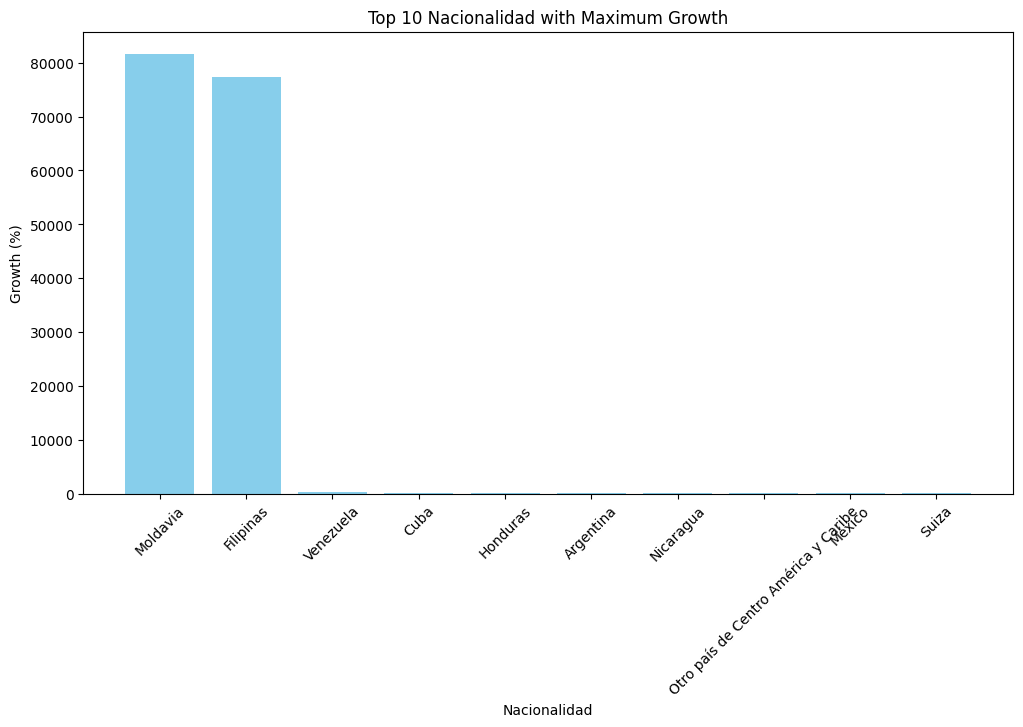

In [41]:
import matplotlib.pyplot as plt

# Display a bar chart of top 10 'Nacionalidad' with max growth
plt.figure(figsize=(12, 6))
plt.bar(top_10_nacionalidad['Nacionalidad'], top_10_nacionalidad['Growth'], color='skyblue')
plt.xlabel('Nacionalidad')
plt.ylabel('Growth (%)')
plt.title('Top 10 Nacionalidad with Maximum Growth')
plt.xticks(rotation=45)
plt.show()

In [42]:
# Calculate the IQR of the 'Growth' column
Q1 = grouped_data['Growth'].quantile(0.25)
Q3 = grouped_data['Growth'].quantile(0.75)
IQR = Q3 - Q1

# Filter the nacionalidades with growth within the IQR
nacionalidades_within_iqr = grouped_data[(grouped_data['Growth'] >= Q1) & (grouped_data['Growth'] <= Q3)]

# Display the nacionalidades with growth within the IQR
nacionalidades_within_iqr

,Nacionalidad,País Nacimiento,Periodo,Total,Growth
47,Argelia,Total,2023,2.233,0.224417
95,Bolivia,Total,2023,9.103,0.964951
111,Brasil,Total,2023,5.759,50.326286
143,Bélgica,Total,2023,37.000,0.000000
159,Canadá,Total,2023,53.000,12.765957
175,Chile,Total,2023,2.020,46.376812
271,De Asia,Total,2023,13.524,2.992918
351,Ecuador,Total,2023,11.326,4.435224
367,Estados Unidos de América,Total,2023,371.000,19.677419
431,Gambia,Total,2023,842.000,11.375661


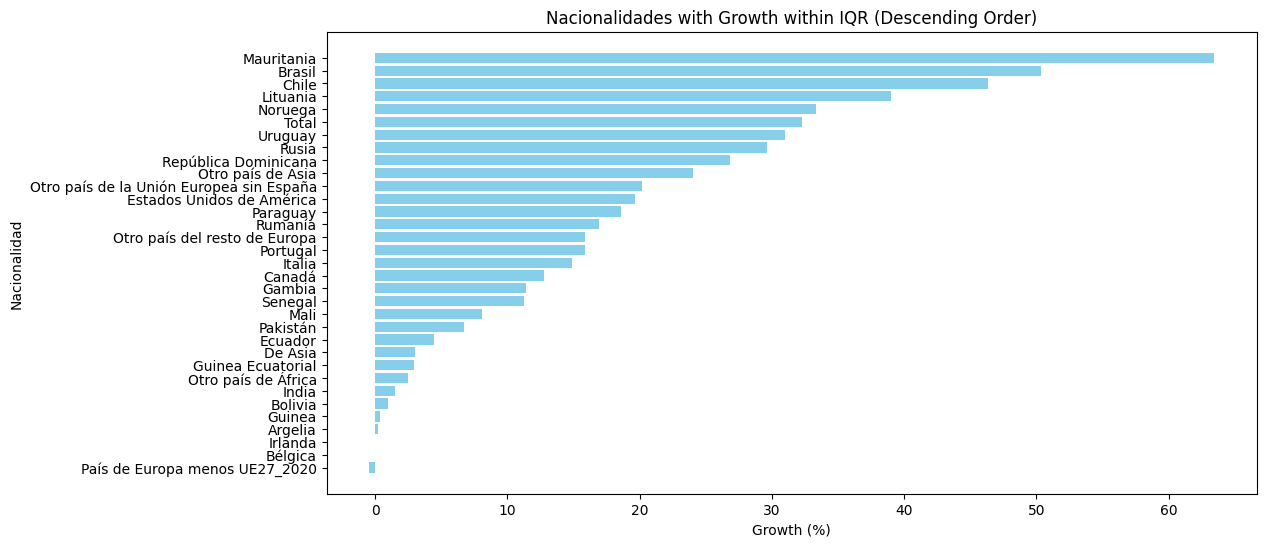

In [43]:
# Sort the nacionalidades with growth within IQR in descending order
nacionalidades_within_iqr_sorted = nacionalidades_within_iqr.sort_values(by='Growth', ascending=True)

# Display a horizontal bar chart of nacionalidades with growth within the IQR in descending order
plt.figure(figsize=(12, 6))
plt.barh(nacionalidades_within_iqr_sorted['Nacionalidad'], nacionalidades_within_iqr_sorted['Growth'], color='skyblue')
plt.xlabel('Growth (%)')
plt.ylabel('Nacionalidad')
plt.title('Nacionalidades with Growth within IQR (Descending Order)')
plt.show()
